<a href="https://colab.research.google.com/github/Konstantinos14/projects/blob/main/EEG_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ERP Analysis of Word Surprisal Using MNE-Python

In [ ]:
!pip install mne
!pip install pandas matplotlib numpy scipy

In [ ]:
import mne
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
raw = mne.io.read_raw_brainvision("S01.vhdr", preload=True)
print(raw.info)


Extracting parameters from S01.vhdr...
Setting channel info structure...
Reading 0 ... 366524  =      0.000 ...   733.048 secs...
<Info | 7 non-empty values
 bads: []
 ch_names: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
 chs: 62 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 62
 projs: []
 sfreq: 500.0 Hz
>


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/tmp/ipython-input-63-677053143.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=50)


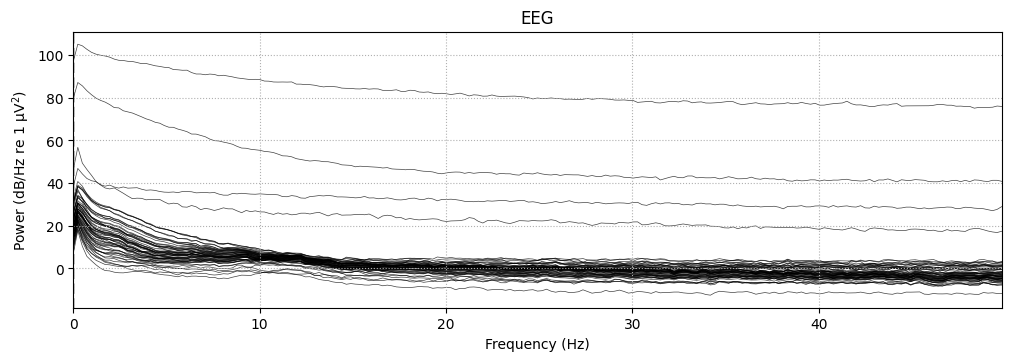

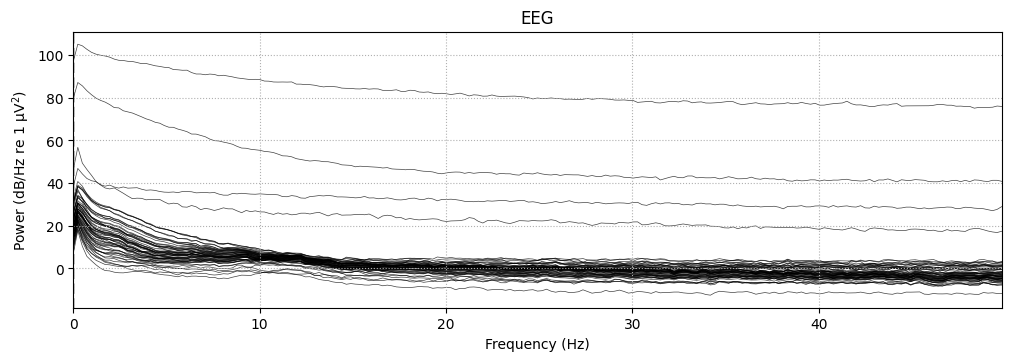

In [ ]:
raw.plot_psd(fmax=50)

In [ ]:
meta = pd.read_csv("AliceChapterOne-EEG.csv")
meta.head()


,Word,Segment,onset,offset,Order,LogFreq,LogFreq_Prev,LogFreq_Next,SndPower,Length,Position,Sentence,IsLexical,NGRAM,RNN,CFG
0,Alice,1,0.046000,0.608721,1,8.65,0.00,14.56,3.621500e-07,0.562721,1,1,1.0,3.226499,3.126175,2.312348
1,was,1,0.562721,0.830543,2,14.56,8.65,10.69,3.843500e-09,0.267822,2,1,0.0,0.905229,1.691128,1.357460
2,beginning,1,0.784543,1.302929,3,10.69,14.56,16.35,3.686500e-09,0.518386,3,1,1.0,4.446766,4.100771,5.626722
3,to,1,1.256929,1.398925,4,16.35,10.69,13.79,3.969700e-09,0.141996,4,1,0.0,2.537495,3.833313,5.939201
4,get,1,1.352925,1.662327,5,13.79,16.35,13.28,3.774700e-09,0.309402,5,1,0.0,1.023137,1.013076,2.697304


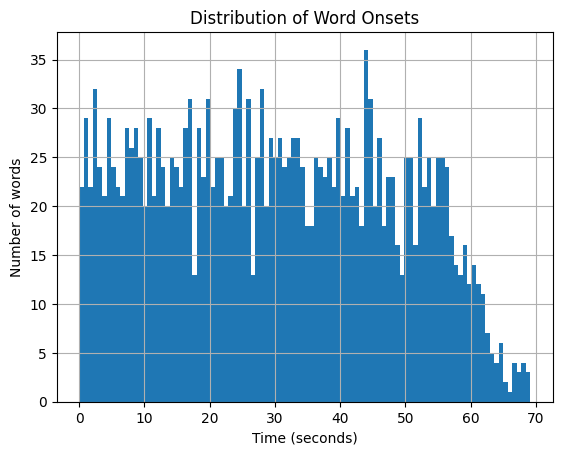

In [ ]:
meta['onset'].hist(bins=100)
plt.title("Distribution of Word Onsets")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of words")
plt.show()


In [ ]:
print(f"EEG duration: {raw.times[-1]:.2f} seconds")
print(f"Max word onset: {meta['onset'].max():.2f} seconds")


EEG duration: 733.05 seconds
Max word onset: 69.13 seconds


In [ ]:
print(raw.info)

<Info | 7 non-empty values
 bads: []
 ch_names: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
 chs: 62 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 62
 projs: []
 sfreq: 500.0 Hz
>


In [ ]:
print(raw.annotations)

<Annotations | 12 segments: Stimulus/1 (1), Stimulus/10 (1), Stimulus/11 ...>


<Info | 7 non-empty values
 bads: []
 ch_names: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
 chs: 62 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 62
 projs: []
 sfreq: 500.0 Hz
>
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/tmp/ipython-input-69-2734886497.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=50)


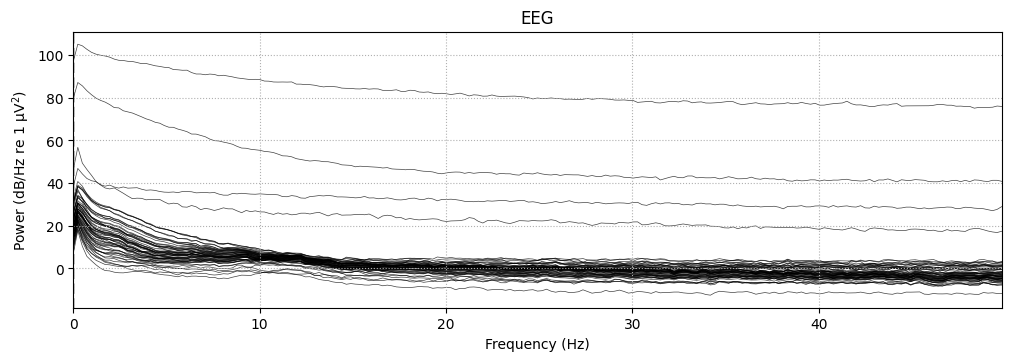

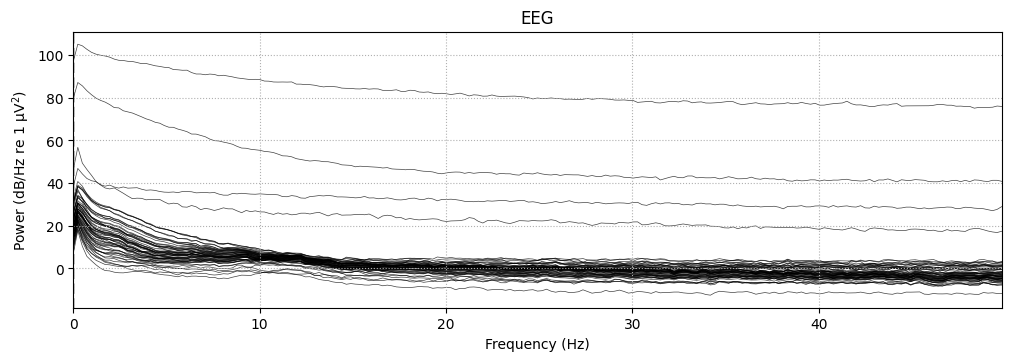

In [ ]:
# Check EEG metadata
print(raw.info)

# Power Spectral Density (to identify noise frequencies)
raw.plot_psd(fmax=50)

In [ ]:
raw_filtered = raw.copy().filter(l_freq=0.1, h_freq=30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 16501 samples (33.002 s)



In [ ]:
raw_filtered.set_eeg_reference('average', projection=True)

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


<RawBrainVision | S01.eeg, 62 x 366525 (733.0 s), ~173.4 MiB, data loaded>

In [ ]:
raw_filtered.set_montage("standard_1020")

ValueError: DigMontage is only a subset of info. There are 62 channel positions not present in the DigMontage. The channels missing from the montage are:

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', 'VEOG', 'Aux5'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.

In [ ]:
# Plot the layout of EEG sensors
raw_filtered.plot_sensors(kind='topomap', show_names=True)

# Optionally flag bad channels
raw_filtered.info['bads'] = ['Fp1']  # Example: mark 'Fp1' as bad

RuntimeError: No valid channel positions found

In [ ]:
raw_filtered.info['bads'] = ['13']  # Replace with actual bad channel name/number

In [ ]:
raw_filtered.info['bads'] = []

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/tmp/ipython-input-77-3356263172.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_filtered.plot_psd(picks=['13'])


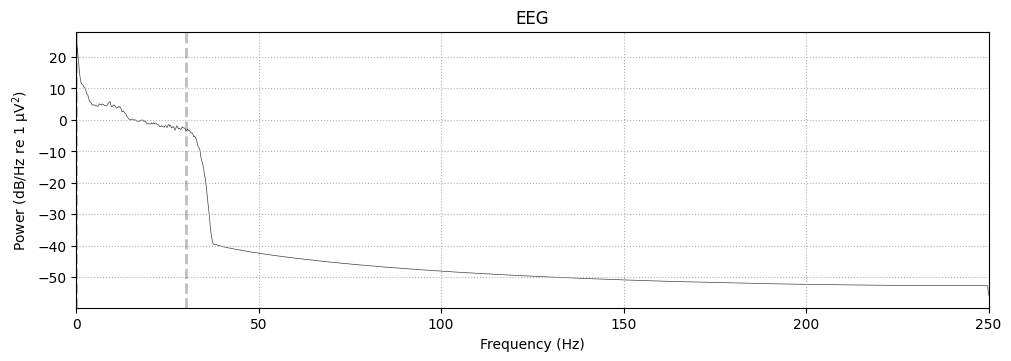

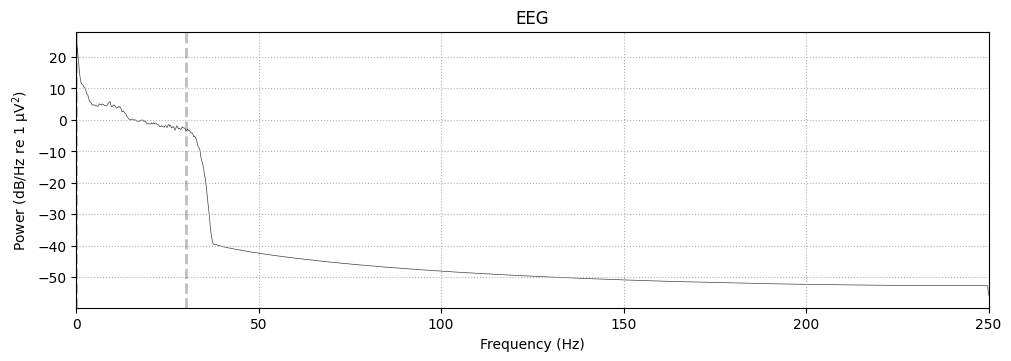

In [ ]:
raw_filtered.plot_psd(picks=['13'])

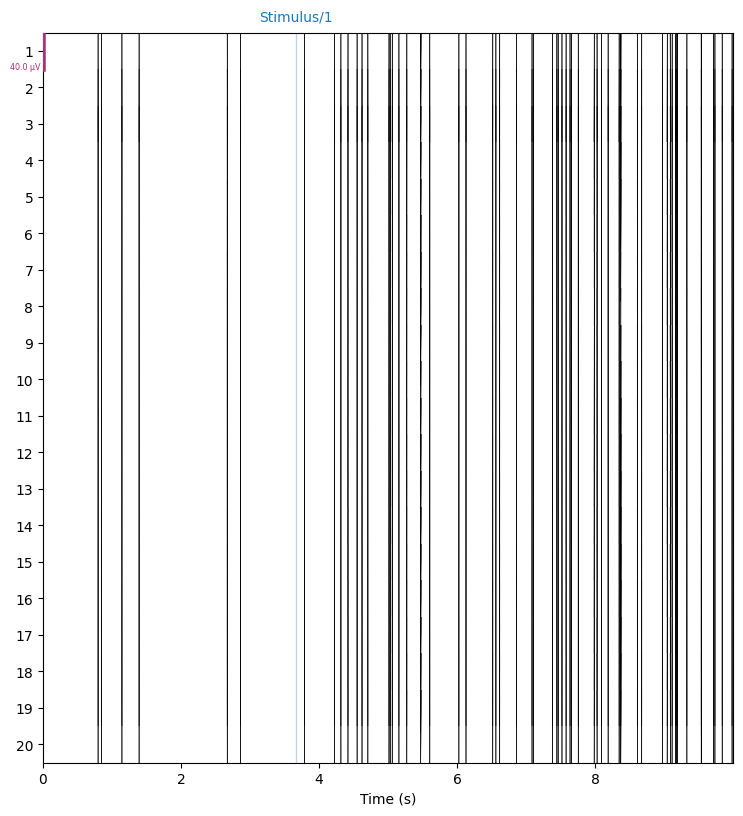

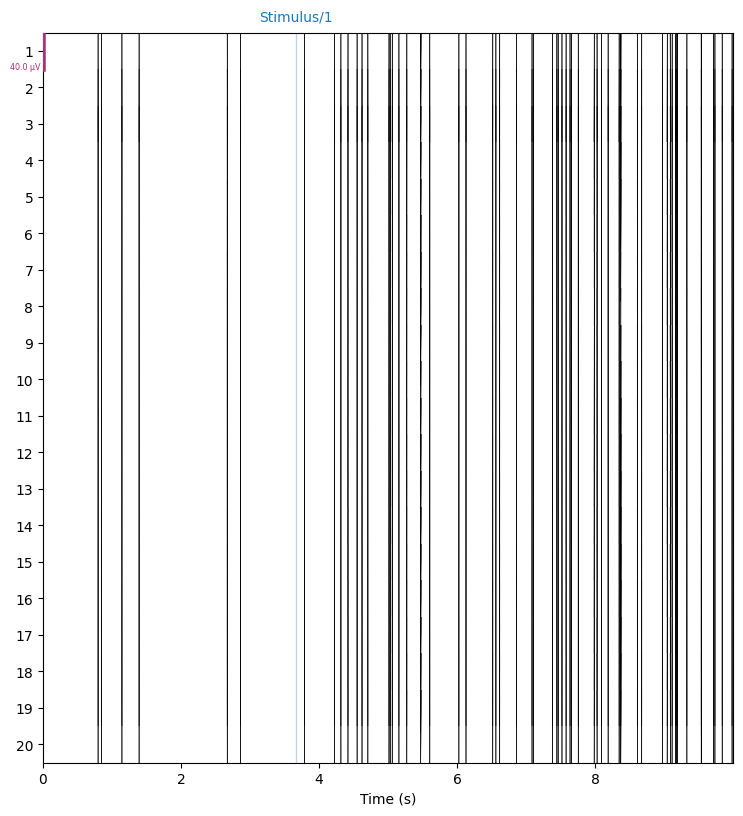

In [ ]:
raw_filtered.plot(start=0, duration=10, n_channels=20, show_scrollbars=False)

In [ ]:
onsets_sec = meta['onset'].values

In [ ]:
sfreq = raw_filtered.info['sfreq']
events = []

for i, t in enumerate(onsets_sec):
    sample = int(t * sfreq)
    events.append([sample, 0, 1])  # We'll use 1 as the event ID for now

import numpy as np
events = np.array(events)

In [ ]:

tmin, tmax = -0.2, 0.8

In [ ]:
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(None, 0),
    preload=True,
    detrend=1
)

RuntimeError: Event time samples were not unique. Consider setting the `event_repeated` parameter."

In [ ]:
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(None, 0),
    preload=True,
    detrend=1,
    event_repeated="merge"  # ✅ FIXES THE ERROR
)


Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
2064 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 2064 events and 501 original time points ...


/tmp/ipython-input-83-3899480696.py:1: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


1 bad epochs dropped


In [ ]:
# Rebuild the events array manually from meta['onset'] to avoid duplicates
sfreq = raw_filtered.info['sfreq']
used_samples = set()
events_clean = []

for onset_sec in meta['onset']:
    sample = int(round(onset_sec * sfreq))
    if sample not in used_samples:
        events_clean.append([sample, 0, 1])  # Use ID=1 for all
        used_samples.add(sample)  # Prevent future duplicates

In [ ]:
import numpy as np
events_clean = np.array(events_clean)

In [ ]:
epochs = mne.Epochs(
    raw_filtered,
    events_clean,
    event_id=1,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    detrend=1
)

Not setting metadata
2071 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 2071 events and 501 original time points ...


/tmp/ipython-input-86-1021894049.py:1: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


1 bad epochs dropped


In [ ]:
epochs.metadata = meta.loc[meta.index[:len(epochs.events)]].reset_index(drop=True)

Adding metadata with 16 columns


In [ ]:
median_surprisal = epochs.metadata['surprisal_rnn'].median()

low_surprisal = epochs[epochs.metadata['surprisal_rnn'] < median_surprisal]
high_surprisal = epochs[epochs.metadata['surprisal_rnn'] >= median_surprisal]

KeyError: 'surprisal_rnn'

In [ ]:
print(epochs.metadata.columns)

Index(['Word', 'Segment', 'onset', 'offset', 'Order', 'LogFreq',
       'LogFreq_Prev', 'LogFreq_Next', 'SndPower', 'Length', 'Position',
       'Sentence', 'IsLexical', 'NGRAM', 'RNN', 'CFG'],
      dtype='object')


In [ ]:
median_surprisal = epochs.metadata['surprisal'].median()

low_surprisal = epochs[epochs.metadata['surprisal'] < median_surprisal]
high_surprisal = epochs[epochs.metadata['surprisal'] >= median_surprisal]

KeyError: 'surprisal'

In [ ]:
print(epochs.metadata.columns.tolist())

['Word', 'Segment', 'onset', 'offset', 'Order', 'LogFreq', 'LogFreq_Prev', 'LogFreq_Next', 'SndPower', 'Length', 'Position', 'Sentence', 'IsLexical', 'NGRAM', 'RNN', 'CFG']


In [ ]:
median_surprisal = epochs.metadata['CORRECT_COLUMN_NAME'].median()

KeyError: 'CORRECT_COLUMN_NAME'

In [ ]:
print(epochs.metadata.columns.tolist())


['Word', 'Segment', 'onset', 'offset', 'Order', 'LogFreq', 'LogFreq_Prev', 'LogFreq_Next', 'SndPower', 'Length', 'Position', 'Sentence', 'IsLexical', 'NGRAM', 'RNN', 'CFG']


In [ ]:
median_surprisal = epochs.metadata['RNN'].median()

low_surprisal = epochs[epochs.metadata['RNN'] < median_surprisal]
high_surprisal = epochs[epochs.metadata['RNN'] >= median_surprisal]

/tmp/ipython-input-95-1502563811.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  low_surprisal.average().plot(spatial_colors=True, titles='Low Surprisal ERP')


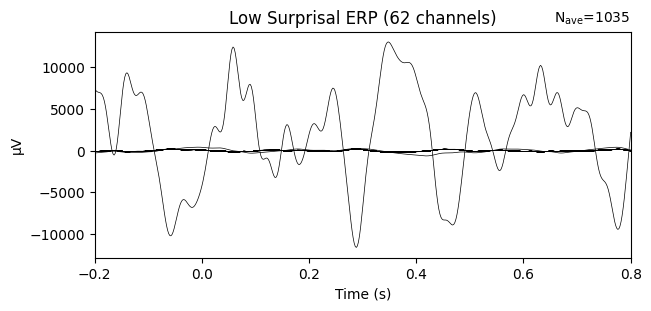

/tmp/ipython-input-95-1502563811.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  high_surprisal.average().plot(spatial_colors=True, titles='High Surprisal ERP')


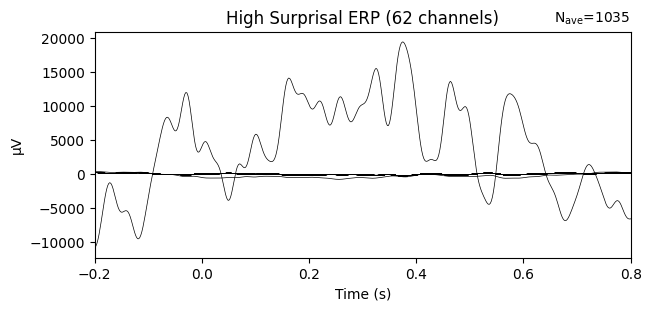

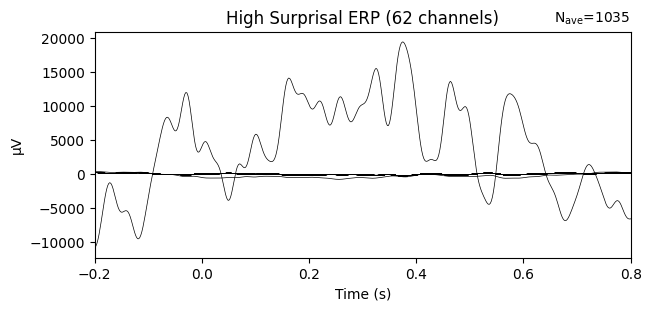

In [ ]:
# Plot average ERP for low surprisal
low_surprisal.average().plot(spatial_colors=True, titles='Low Surprisal ERP')

# Plot average ERP for high surprisal
high_surprisal.average().plot(spatial_colors=True, titles='High Surprisal ERP')

In [ ]:
# Topomap at 400 ms for low surprisal
low_surprisal.average().plot_topomap(times=0.4, title='Low Surprisal - 400ms')

# Topomap at 400 ms for high surprisal
high_surprisal.average().plot_topomap(times=0.4, title='High Surprisal - 400ms')

TypeError: Evoked.plot_topomap() got an unexpected keyword argument 'title'

In [ ]:
import matplotlib.pyplot as plt

# Plot topomap for low surprisal at 400 ms
low_surprisal.average().plot_topomap(times=0.4, colorbar=True)
plt.suptitle("Low Surprisal – 400ms")

# Plot topomap for high surprisal at 400 ms
high_surprisal.average().plot_topomap(times=0.4, colorbar=True)
plt.suptitle("High Surprisal – 400ms")

RuntimeError: No digitization points found.

In [ ]:
raw_filtered.set_montage('standard_1020', on_missing='ignore')

<RawBrainVision | S01.eeg, 62 x 366525 (733.0 s), ~173.4 MiB, data loaded>

In [ ]:
epochs.set_montage('standard_1020', on_missing='ignore')

<Epochs | 2070 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~490.6 MiB, data loaded, with metadata,
 '1': 2070>

In [ ]:
low_surprisal.average().plot_topomap(times=0.4, colorbar=True)
plt.suptitle("Low Surprisal – 400ms")

high_surprisal.average().plot_topomap(times=0.4, colorbar=True)
plt.suptitle("High Surprisal – 400ms")

RuntimeError: No digitization points found.

Not setting metadata
1035 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


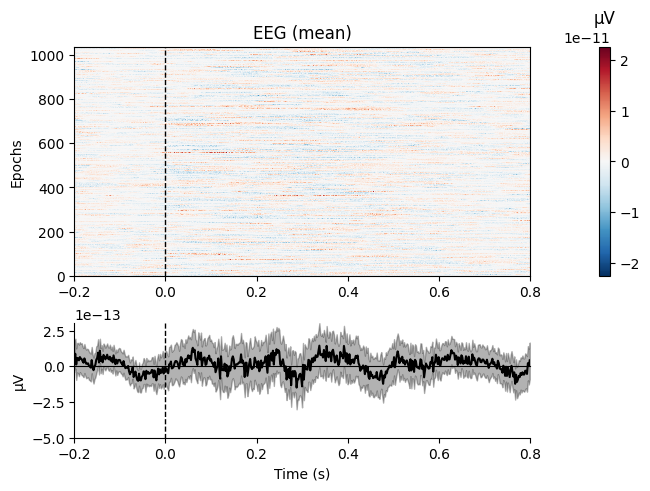

Not setting metadata
1035 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


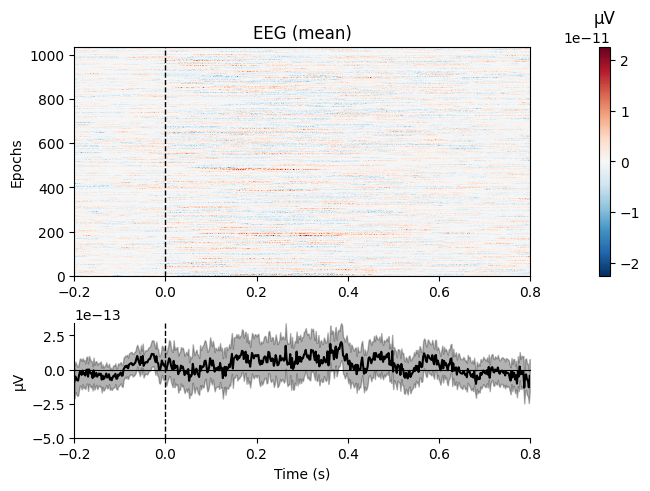

[<Figure size 640x480 with 3 Axes>]

In [ ]:
low_surprisal.plot_image(picks='eeg', combine='mean')
high_surprisal.plot_image(picks='eeg', combine='mean')

In [ ]:
evoked_low = low_surprisal.average()
evoked_high = high_surprisal.average()

In [ ]:
import mne

mne.viz.plot_compare_evokeds(
    {'Low Surprisal': evoked_low, 'High Surprisal': evoked_high},
    picks='Cz',  # You can also try 'Pz' or 'FCz'
    combine='mean',  # averages across the picked channels
    title='ERP Comparison at Cz'
)

ValueError: picks ('Cz') could not be interpreted as channel names (no channel "[np.str_('Cz')]"), channel types (no type "Cz" present), or a generic type (just "all" or "data")

combining channels using "mean"
combining channels using "mean"


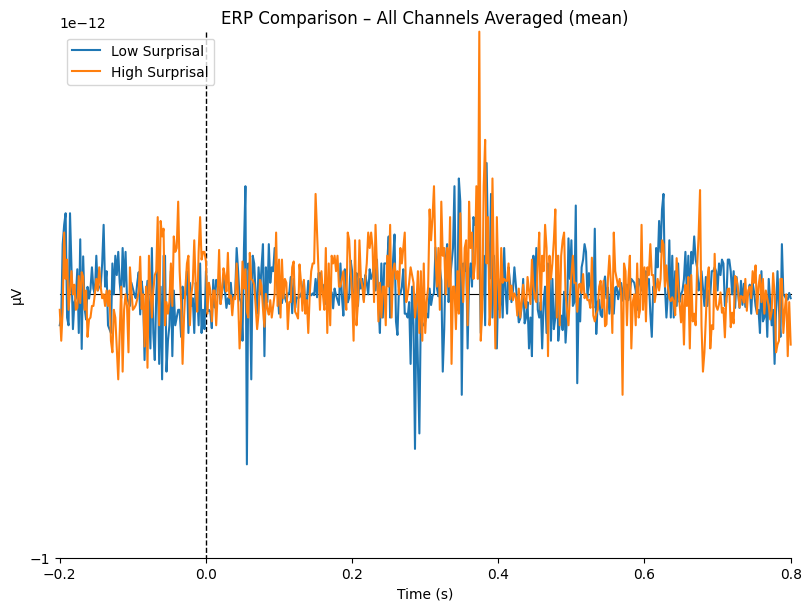

[<Figure size 800x600 with 1 Axes>]

In [ ]:
mne.viz.plot_compare_evokeds(
    {'Low Surprisal': evoked_low, 'High Surprisal': evoked_high},
    combine='mean',
    title='ERP Comparison – All Channels Averaged'
)

In [ ]:
print(evoked_low.info['ch_names'])

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', 'VEOG', 'Aux5']


combining channels using "mean"
combining channels using "mean"


/tmp/ipython-input-106-215514766.py:1: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(
/tmp/ipython-input-106-215514766.py:1: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(


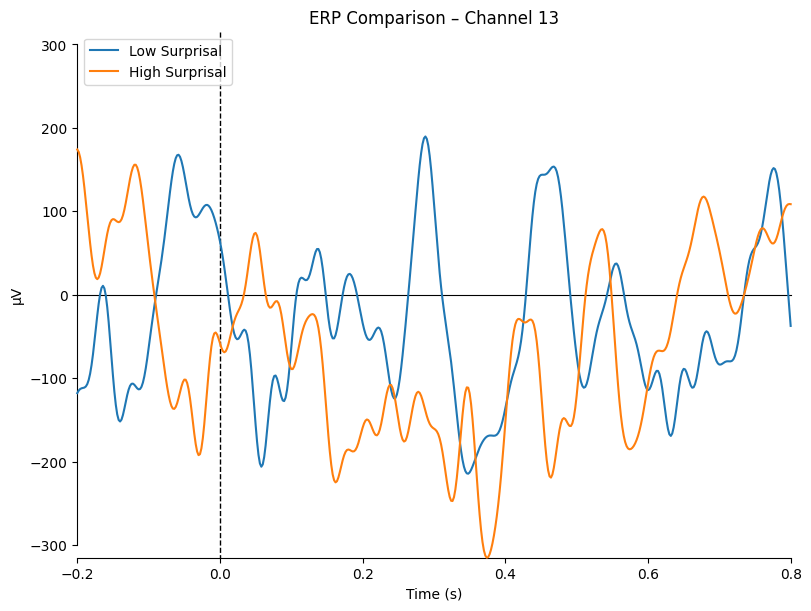

[<Figure size 800x600 with 1 Axes>]

In [ ]:
mne.viz.plot_compare_evokeds(
    {'Low Surprisal': evoked_low, 'High Surprisal': evoked_high},
    picks='13',  # or whatever matches your data
    combine='mean',
    title='ERP Comparison – Channel 13'
)

/tmp/ipython-input-107-2591517156.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  diff.plot(spatial_colors=True, titles='Difference Wave: High - Low Surprisal')


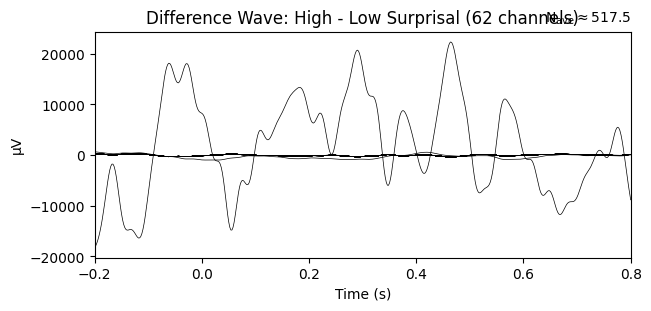

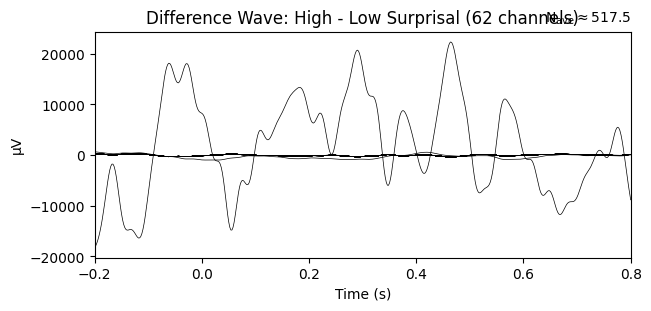

In [ ]:
diff = mne.combine_evoked([evoked_high, evoked_low], weights=[1, -1])
diff.plot(spatial_colors=True, titles='Difference Wave: High - Low Surprisal')

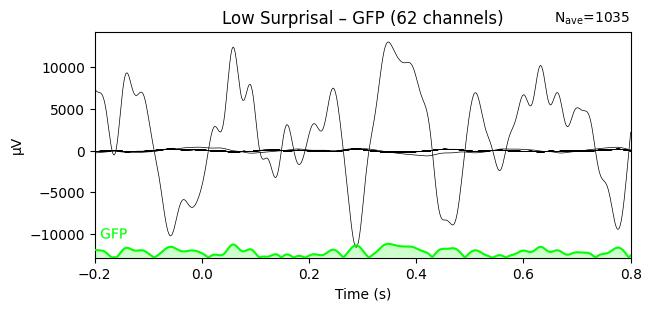

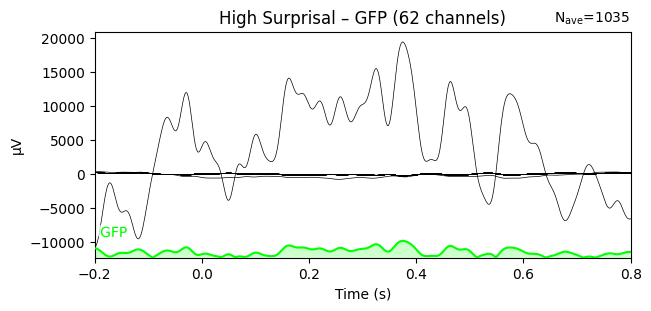

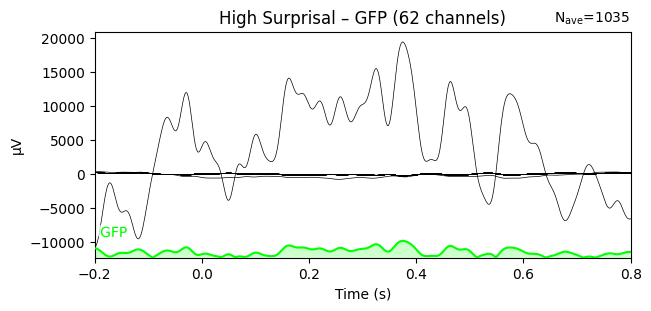

In [ ]:
evoked_low.plot(gfp=True, titles='Low Surprisal – GFP')
evoked_high.plot(gfp=True, titles='High Surprisal – GFP')

In [ ]:
fig = mne.viz.plot_compare_evokeds(
    {'Low Surprisal': evoked_low, 'High Surprisal': evoked_high},
    combine='mean'
)
fig.savefig('erp_comparison_channel13.png'

SyntaxError: incomplete input (ipython-input-109-3720430091.py, line 5)

In [ ]:
evoked_low.save('evoked_low-ave.fif', overwrite=True)
evoked_high.save('evoked_high-ave.fif', overwrite=True)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


In [ ]:
X_low = low_surprisal.get_data()
X_high = high_surprisal.get_data()

In [ ]:
print("Low:", X_low.shape, "High:", X_high.shape)

Low: (1035, 62, 501) High: (1035, 62, 501)


In [ ]:
low_n400 = low_surprisal.copy().crop(tmin=0.3, tmax=0.5).get_data()
high_n400 = high_surprisal.copy().crop(tmin=0.3, tmax=0.5).get_data()

In [ ]:
import numpy as np

X = np.concatenate([low_n400, high_n400], axis=0)
y = np.array([0] * len(low_n400) + [1] * len(high_n400))

In [ ]:
from mne.channels import find_ch_adjacency

adjacency, _ = find_ch_adjacency(low_surprisal.info, ch_type='eeg')

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.


RuntimeError: No digitization points found.

In [ ]:
# Extract data from 300 ms to 500 ms
low_data = low_surprisal.copy().crop(tmin=0.3, tmax=0.5).get_data()
high_data = high_surprisal.copy().crop(tmin=0.3, tmax=0.5).get_data()

# Average across channels → shape becomes (n_epochs, n_times)
low_mean = low_data.mean(axis=1)
high_mean = high_data.mean(axis=1)


In [ ]:
from mne.stats import permutation_t_test
import numpy as np

# Combine data
X = np.concatenate([low_mean, high_mean], axis=0)
labels = np.array([0] * len(low_mean) + [1] * len(high_mean))

# Run permutation test
T_obs, p_values, H0 = permutation_t_test(X, n_permutations=1000, tail=0, n_jobs=1)


Permuting 999 times...


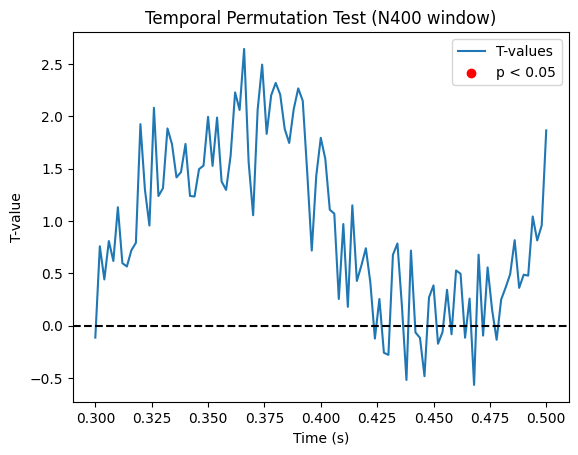

In [ ]:
import matplotlib.pyplot as plt

# Time vector for the N400 window
times = low_surprisal.times[
    low_surprisal.time_as_index(0.3)[0] : low_surprisal.time_as_index(0.5)[0] + 1
]

# Plot T-values and significant points
plt.plot(times, T_obs, label='T-values')
plt.axhline(0, color='black', linestyle='--')
plt.scatter(times[p_values < 0.05], T_obs[p_values < 0.05], color='red', label='p < 0.05')

plt.xlabel("Time (s)")
plt.ylabel("T-value")
plt.title("Temporal Permutation Test (N400 window)")
plt.legend()
plt.show()
